In [1]:
from google.colab import files

uploaded = files.upload()

Saving aclImdb_v1.tar.gz to aclImdb_v1.tar.gz


In [2]:
import tarfile

with tarfile.open("aclImdb_v1.tar.gz", "r:gz") as tar:
    tar.extractall()

/tmp/ipykernel_1717/537903209.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


In [3]:
import os

for root, dirs, files in os.walk('/content'):
    print(root)
    if len(files) > 0:
        print("Files:", files[:5])
    print("-"*50)

/content
Files: ['aclImdb_v1.tar.gz']
--------------------------------------------------
/content/.config
Files: ['.last_opt_in_prompt.yaml', '.last_update_check.json', 'hidden_gcloud_config_universe_descriptor_data_cache_configs.db', 'active_config', 'config_sentinel']
--------------------------------------------------
/content/.config/configurations
Files: ['config_default']
--------------------------------------------------
/content/.config/logs
--------------------------------------------------
/content/.config/logs/2026.05.26
Files: ['13.31.22.451851.log', '13.30.34.238876.log', '13.31.08.786403.log', '13.30.51.777284.log', '13.31.07.426506.log']
--------------------------------------------------
/content/aclImdb
Files: ['imdb.vocab', 'README', 'imdbEr.txt']
--------------------------------------------------
/content/aclImdb/test
Files: ['urls_neg.txt', 'labeledBow.feat', 'urls_pos.txt']
--------------------------------------------------
/content/aclImdb/test/pos
Files: ['8419_10.

In [4]:
import math
import torch
import torch.nn as nn

class PositionalEncoding(nn.Module):

    def __init__(self,d_model,max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len,d_model)

        position = torch.arange(0,max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0,d_model,2)
            * (-math.log(10000.0)/d_model)
        )

        pe[:,0::2] = torch.sin(position*div_term)
        pe[:,1::2] = torch.cos(position*div_term)

        self.register_buffer(
            "pe",
            pe.unsqueeze(0)
        )

    def forward(self,x):

        return x + self.pe[:,:x.size(1)]


class SentimentTransformer(nn.Module):

    def __init__(
        self,
        vocab_size,
        d_model=128,
        nhead=8,
        num_layers=2,
        num_classes=2
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        self.pos_encoder = PositionalEncoding(
            d_model
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.fc = nn.Linear(
            d_model,
            num_classes
        )

    def forward(self,x):

        x = self.embedding(x)

        x = self.pos_encoder(x)

        x = self.transformer(x)

        x = x.mean(dim=1)

        x = self.fc(x)

        return x

Device: cuda
Training Reviews: 5000
['if', 'you', 'like', 'deep', 'purple', 'you', 'will', 'enjoy', 'in', 'this', 'excellent', 'movie', 'with', 'stephen', 'rea', 'in', 'main', 'role', 'the', 'story']
Vocabulary Size: 15002
Epoch 1
Loss: 0.7156
Accuracy: 51.12%
----------------------------------------
Epoch 2
Loss: 0.6321
Accuracy: 62.60%
----------------------------------------
Epoch 3
Loss: 0.4784
Accuracy: 76.80%
----------------------------------------
Epoch 4
Loss: 0.3772
Accuracy: 83.02%
----------------------------------------
Epoch 5
Loss: 0.2744
Accuracy: 88.18%
----------------------------------------


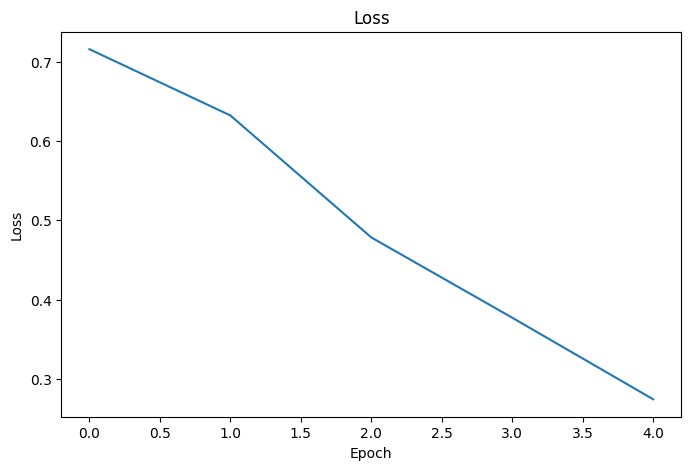

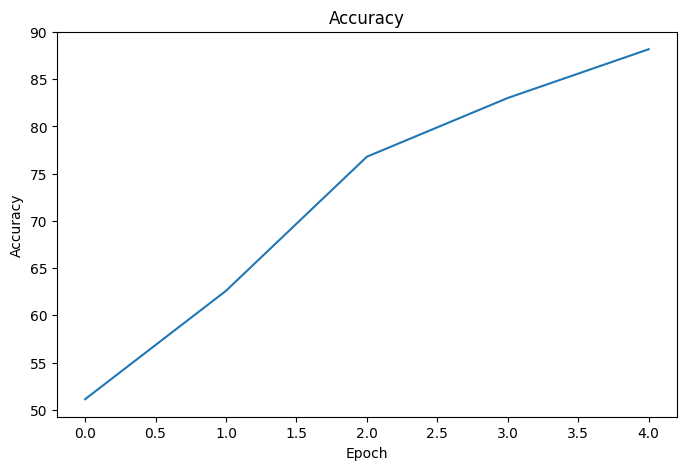

Test Accuracy: 76.8
              precision    recall  f1-score   support

           0       0.72      0.87      0.79      1000
           1       0.84      0.66      0.74      1000

    accuracy                           0.77      2000
   macro avg       0.78      0.77      0.77      2000
weighted avg       0.78      0.77      0.77      2000

[[874 126]
 [338 662]]


In [5]:

import os
import re
import math
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from collections import Counter

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

train_pos = "/content/aclImdb/train/pos"
train_neg = "/content/aclImdb/train/neg"

test_pos = "/content/aclImdb/test/pos"
test_neg = "/content/aclImdb/test/neg"

reviews = []
labels = []
def load_reviews(folder,label,max_files=None):

    files = os.listdir(folder)

    if max_files:
        files = files[:max_files]

    for file in files:

        path = os.path.join(folder,file)

        with open(
            path,
            encoding="utf8"
        ) as f:

            reviews.append(
                f.read()
            )

            labels.append(label)
load_reviews(
    train_pos,
    1,
    2500
)

load_reviews(
    train_neg,
    0,
    2500
)

print("Training Reviews:",len(reviews))



def clean_text(text):

    text = text.lower()

    text = re.sub(
        r"<.*?>",
        "",
        text
    )

    text = re.sub(
        r"[^a-zA-Z ]",
        "",
        text
    )

    return text
reviews = [
    clean_text(x)
    for x in reviews
]

tokenized_reviews = [
    review.split()
    for review in reviews
]
print(tokenized_reviews[0][:20])

counter = Counter()

for review in tokenized_reviews:

    counter.update(review)
vocab = {
    word:i+2
    for i,(word,count)
    in enumerate(
        counter.most_common(15000)
    )
}

vocab["<PAD>"] = 0
vocab["<UNK>"] = 1
print("Vocabulary Size:",len(vocab))

MAX_LEN = 200
def encode_review(tokens):

    encoded = [
        vocab.get(
            word,
            vocab["<UNK>"]
        )
        for word in tokens
    ]

    encoded = encoded[:MAX_LEN]

    while len(encoded) < MAX_LEN:
        encoded.append(0)

    return encoded
encoded_reviews = [
    encode_review(x)
    for x in tokenized_reviews
]

class IMDBDataset(Dataset):

    def __init__(
        self,
        reviews,
        labels
    ):
        self.reviews = reviews
        self.labels = labels

    def __len__(self):
        return len(self.reviews)

    def __getitem__(self,idx):

        return (
            torch.tensor(
                self.reviews[idx],
                dtype=torch.long
            ),
            torch.tensor(
                self.labels[idx],
                dtype=torch.long
            )
        )

dataset = IMDBDataset(
    encoded_reviews,
    labels
)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

class PositionalEncoding(nn.Module):

    def __init__(
        self,
        d_model,
        max_len=5000
    ):
        super().__init__()

        pe = torch.zeros(
            max_len,
            d_model
        )

        position = torch.arange(
            0,
            max_len
        ).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(
                0,
                d_model,
                2
            )
            *
            (
                -math.log(10000.0)
                / d_model
            )
        )

        pe[:,0::2] = torch.sin(
            position*div_term
        )

        pe[:,1::2] = torch.cos(
            position*div_term
        )

        self.register_buffer(
            "pe",
            pe.unsqueeze(0)
        )

    def forward(self,x):

        return x + self.pe[:,:x.size(1)]

class SentimentTransformer(nn.Module):

    def __init__(
        self,
        vocab_size,
        d_model=128,
        nhead=8,
        layers=2
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        self.positional = PositionalEncoding(
            d_model
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=layers
        )

        self.fc = nn.Linear(
            d_model,
            2
        )

    def forward(self,x):

        x = self.embedding(x)

        x = self.positional(x)

        x = self.transformer(x)

        x = x.mean(dim=1)

        x = self.fc(x)

        return x

model = SentimentTransformer(
    len(vocab)
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005
)

EPOCHS = 5

loss_history = []
acc_history = []
for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for X,y in loader:

        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        outputs = model(X)

        loss = criterion(
            outputs,
            y
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _,predicted = torch.max(
            outputs,
            1
        )

        total += y.size(0)

        correct += (
            predicted == y
        ).sum().item()

    epoch_loss = (
        running_loss
        /
        len(loader)
    )

    epoch_acc = (
        100
        *
        correct
        /
        total
    )

    loss_history.append(
        epoch_loss
    )

    acc_history.append(
        epoch_acc
    )

    print(
        f"Epoch {epoch+1}"
    )

    print(
        f"Loss: {epoch_loss:.4f}"
    )

    print(
        f"Accuracy: {epoch_acc:.2f}%"
    )

    print("-"*40)

plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.title("Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

plt.figure(figsize=(8,5))

plt.plot(acc_history)

plt.title("Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

test_reviews = []
test_labels = []
def load_test(folder,label):

    files = os.listdir(folder)[:1000]

    for file in files:

        path = os.path.join(folder,file)

        with open(
            path,
            encoding="utf8"
        ) as f:

            test_reviews.append(
                clean_text(
                    f.read()
                )
            )

            test_labels.append(
                label
            )
load_test(
    test_pos,
    1
)

load_test(
    test_neg,
    0
)

test_encoded = [
    encode_review(
        review.split()
    )
    for review in test_reviews
]

model.eval()

preds = []

with torch.no_grad():

    for review in test_encoded:

        tensor = torch.tensor(
            review
        ).unsqueeze(0).to(device)

        output = model(
            tensor
        )

        prediction = torch.argmax(
            output,
            dim=1
        )

        preds.append(
            prediction.item()
        )

accuracy = accuracy_score(
    test_labels,
    preds
)

print(
    "Test Accuracy:",
    accuracy*100
)

print(
    classification_report(
        test_labels,
        preds
    )
)

print(
    confusion_matrix(
        test_labels,
        preds
    )
)

def predict_review(text):

    text = clean_text(text)

    encoded = encode_review(
        text.split()
    )

    tensor = torch.tensor(
        encoded
    ).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        output = model(
            tensor
        )

        prob = torch.softmax(
            output,
            dim=1
        )

        pred = torch.argmax(
            prob,
            dim=1
        ).item()

        confidence = (
            prob.max().item()
            *100
        )

    sentiment = (
        "Positive"
        if pred==1
        else "Negative"
    )

    print(
        "Prediction:",
        sentiment
    )

    print(
        "Confidence:",
        round(confidence,2),
        "%"
    )

In [6]:
predict_review(
    "This movie was absolutely amazing and brilliant"
)

Prediction: Positive
Confidence: 99.57 %


In [7]:
predict_review(
    "Worst movie I have ever watched"
)

Prediction: Negative
Confidence: 99.53 %


Device: cuda
Training Reviews: 20000
Vocabulary Size: 15002


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 1
Train Loss: 0.6701
Train Accuracy: 58.74%
Validation Loss: 0.6179
Validation Accuracy: 67.78%
--------------------------------------------------
Epoch 2
Train Loss: 0.5642
Train Accuracy: 71.76%
Validation Loss: 0.5869
Validation Accuracy: 69.97%
--------------------------------------------------
Epoch 3
Train Loss: 0.5574
Train Accuracy: 72.16%
Validation Loss: 0.6047
Validation Accuracy: 70.72%
--------------------------------------------------
Early Stop Counter: 1/3
Epoch 4
Train Loss: 0.5633
Train Accuracy: 71.31%
Validation Loss: 0.6229
Validation Accuracy: 68.53%
--------------------------------------------------
Early Stop Counter: 2/3
Epoch 5
Train Loss: 0.5480
Train Accuracy: 72.97%
Validation Loss: 0.6320
Validation Accuracy: 69.47%
--------------------------------------------------
Early Stop Counter: 3/3
EARLY STOPPING TRIGGERED


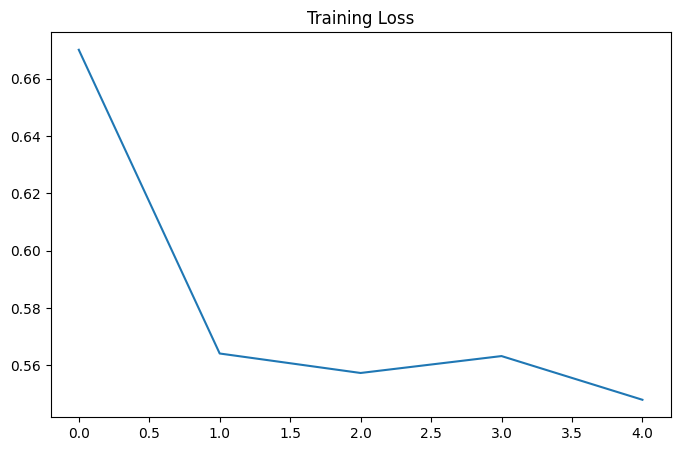

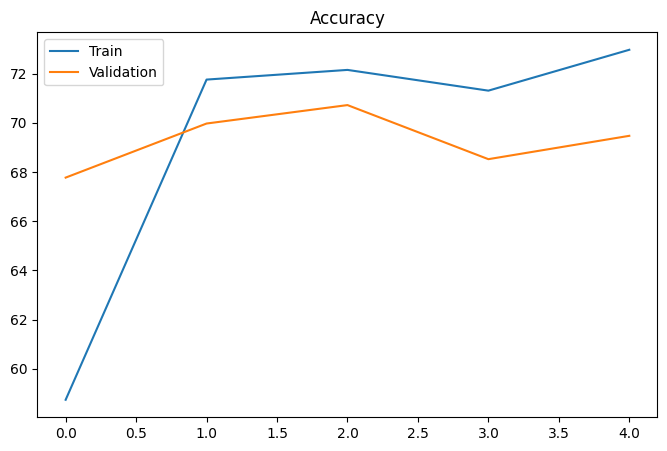


Test Accuracy: 71.75

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.54      0.65      1000
           1       0.66      0.90      0.76      1000

    accuracy                           0.72      2000
   macro avg       0.75      0.72      0.71      2000
weighted avg       0.75      0.72      0.71      2000


Confusion Matrix
[[536 464]
 [101 899]]


In [8]:

# imdb_transformer_final.py
# Complete IMDb Transformer Sentiment Analysis with:
# - Positional Encoding
# - Transformer Encoder
# - Validation Split
# - Early Stopping
# - Dropout
# - Gradient Clipping
# - Best Model Saving
# - Loss/Accuracy Graphs
# - Test Evaluation
# - Classification Report
# - Confusion Matrix
# - Confidence Prediction

import os
import re
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

TRAIN_POS = "/content/aclImdb/train/pos"
TRAIN_NEG = "/content/aclImdb/train/neg"
TEST_POS = "/content/aclImdb/test/pos"
TEST_NEG = "/content/aclImdb/test/neg"

MAX_LEN = 300
VOCAB_SIZE = 15000
BATCH_SIZE = 32
D_MODEL = 256
NHEAD = 8
LAYERS = 3
LR = 5e-4
EPOCHS = 15
PATIENCE = 3

reviews = []
labels = []

def load_reviews(folder, label, max_files=None):
    files = os.listdir(folder)
    if max_files:
        files = files[:max_files]
    for file in files:
        path = os.path.join(folder, file)
        with open(path, encoding="utf8") as f:
            reviews.append(f.read())
            labels.append(label)

load_reviews(TRAIN_POS, 1, 10000)
load_reviews(TRAIN_NEG, 0, 10000)

print("Training Reviews:", len(reviews))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)
    return text

reviews = [clean_text(x) for x in reviews]
tokenized_reviews = [x.split() for x in reviews]

counter = Counter()
for review in tokenized_reviews:
    counter.update(review)

vocab = {
    word: i + 2
    for i, (word, count) in enumerate(counter.most_common(VOCAB_SIZE))
}

vocab["<PAD>"] = 0
vocab["<UNK>"] = 1

print("Vocabulary Size:", len(vocab))

def encode_review(tokens):
    encoded = [vocab.get(word, 1) for word in tokens]
    encoded = encoded[:MAX_LEN]
    encoded += [0] * (MAX_LEN - len(encoded))
    return encoded

encoded_reviews = [encode_review(x) for x in tokenized_reviews]

X_train, X_val, y_train, y_val = train_test_split(
    encoded_reviews,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

class IMDBDataset(Dataset):
    def __init__(self, reviews, labels):
        self.reviews = reviews
        self.labels = labels

    def __len__(self):
        return len(self.reviews)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.reviews[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

train_dataset = IMDBDataset(X_train, y_train)
val_dataset = IMDBDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) *
            (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class SentimentTransformer(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, D_MODEL)
        self.positional = PositionalEncoding(D_MODEL)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL,
            nhead=NHEAD,
            dropout=0.3,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=LAYERS
        )

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(D_MODEL, 2)

    def forward(self, x):
        mask = (x == 0)

        x = self.embedding(x)
        x = self.positional(x)

        x = self.transformer(
            x,
            src_key_padding_mask=mask
        )

        x = x.mean(dim=1)
        x = self.dropout(x)

        return self.fc(x)

model = SentimentTransformer(len(vocab)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_val_loss = float("inf")
counter_stop = 0

train_loss_history = []
train_acc_history = []
val_acc_history = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for X, y in train_loader:

        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        outputs = model(X)

        loss = criterion(outputs, y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        running_loss += loss.item()

        _, pred = torch.max(outputs, 1)

        total += y.size(0)
        correct += (pred == y).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for X, y in val_loader:

            X = X.to(device)
            y = y.to(device)

            outputs = model(X)

            loss = criterion(outputs, y)

            val_loss += loss.item()

            _, pred = torch.max(outputs, 1)

            val_total += y.size(0)
            val_correct += (pred == y).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.2f}%")
    print("-"*50)

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        counter_stop = 0

        torch.save(
            model.state_dict(),
            "best_transformer.pth"
        )

    else:

        counter_stop += 1

        print(
            f"Early Stop Counter: {counter_stop}/{PATIENCE}"
        )

        if counter_stop >= PATIENCE:

            print("EARLY STOPPING TRIGGERED")
            break

model.load_state_dict(
    torch.load("best_transformer.pth")
)

plt.figure(figsize=(8,5))
plt.plot(train_loss_history)
plt.title("Training Loss")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(train_acc_history, label="Train")
plt.plot(val_acc_history, label="Validation")
plt.legend()
plt.title("Accuracy")
plt.show()

test_reviews = []
test_labels = []

def load_test(folder, label):

    files = os.listdir(folder)[:1000]

    for file in files:

        path = os.path.join(folder, file)

        with open(path, encoding="utf8") as f:

            test_reviews.append(clean_text(f.read()))
            test_labels.append(label)

load_test(TEST_POS, 1)
load_test(TEST_NEG, 0)

test_encoded = [
    encode_review(x.split())
    for x in test_reviews
]

preds = []

model.eval()

with torch.no_grad():

    for review in test_encoded:

        tensor = torch.tensor(review).unsqueeze(0).to(device)

        output = model(tensor)

        prediction = torch.argmax(output, dim=1)

        preds.append(prediction.item())

acc = accuracy_score(test_labels, preds)

print("\nTest Accuracy:", round(acc*100,2))

print("\nClassification Report")
print(classification_report(test_labels, preds))

print("\nConfusion Matrix")
print(confusion_matrix(test_labels, preds))

def predict_review(text):

    text = clean_text(text)

    encoded = encode_review(text.split())

    tensor = torch.tensor(encoded).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        output = model(tensor)

        probs = torch.softmax(output, dim=1)

        pred = torch.argmax(probs, dim=1).item()

        confidence = probs.max().item() * 100

    sentiment = "Positive" if pred == 1 else "Negative"

    print("Prediction:", sentiment)
    print("Confidence:", round(confidence,2), "%")

In [9]:
predict_review(
    "This movie was absolutely amazing and brilliant"
)

Prediction: Positive
Confidence: 50.39 %


In [10]:
predict_review(
    "Worst movie I have ever watched"
)

Prediction: Negative
Confidence: 52.24 %


In [11]:
!pip install transformers datasets accelerate -q

In [12]:
import os
import torch
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

from datasets import Dataset

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

train_pos = "/content/aclImdb/train/pos"
train_neg = "/content/aclImdb/train/neg"

test_pos = "/content/aclImdb/test/pos"
test_neg = "/content/aclImdb/test/neg"

train_texts = []
train_labels = []

test_texts = []
test_labels = []

def load_reviews(folder,label,limit=None):

    files = os.listdir(folder)

    if limit:
        files = files[:limit]

    for file in files:

        path = os.path.join(folder,file)

        with open(
            path,
            encoding="utf8"
        ) as f:

            text = f.read()

            if label is not None:
                train_texts.append(text)
                train_labels.append(label)

def load_test(folder,label,limit=None):

    files = os.listdir(folder)

    if limit:
        files = files[:limit]

    for file in files:

        path = os.path.join(folder,file)

        with open(
            path,
            encoding="utf8"
        ) as f:

            test_texts.append(
                f.read()
            )

            test_labels.append(label)

load_reviews(
    train_pos,
    1,
    5000
)

load_reviews(
    train_neg,
    0,
    5000
)

load_test(
    test_pos,
    1,
    1000
)

load_test(
    test_neg,
    0,
    1000
)

print("Training Samples:",len(train_texts))
print("Testing Samples:",len(test_texts))

tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=256
)

train_dataset = Dataset.from_dict({
    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "labels": train_labels
})

test_dataset = Dataset.from_dict({
    "input_ids": test_encodings["input_ids"],
    "attention_mask": test_encodings["attention_mask"],
    "labels": test_labels
})

def compute_metrics(pred):

    labels = pred.label_ids

    preds = pred.predictions.argmax(-1)

    acc = accuracy_score(
        labels,
        preds
    )

    return {
        "accuracy": acc
    }

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=100,
    fp16=torch.cuda.is_available()
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

trainer.train()

predictions = trainer.predict(
    test_dataset
)

preds = np.argmax(
    predictions.predictions,
    axis=1
)

accuracy = accuracy_score(
    test_labels,
    preds
)

print("\nTest Accuracy:")
print(round(accuracy*100,2),"%")

print("\nClassification Report")
print(
    classification_report(
        test_labels,
        preds
    )
)

print("\nConfusion Matrix")
print(
    confusion_matrix(
        test_labels,
        preds
    )
)

model.save_pretrained(
    "best_distilbert_model"
)

tokenizer.save_pretrained(
    "best_distilbert_model"
)

print("\nModel Saved")

Device: cuda
Training Samples: 10000
Testing Samples: 2000


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Test Accuracy:
90.7 %

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      1000
           1       0.91      0.90      0.91      1000

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000


Confusion Matrix
[[911  89]
 [ 97 903]]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model Saved


In [13]:
def predict_review(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    inputs = {
        k:v.to(device)
        for k,v in inputs.items()
    }

    model.to(device)

    model.eval()

    with torch.no_grad():

        outputs = model(**inputs)

        probs = torch.softmax(
            outputs.logits,
            dim=1
        )

        pred = torch.argmax(
            probs,
            dim=1
        ).item()

        confidence = (
            probs.max().item()*100
        )

    sentiment = (
        "Positive"
        if pred==1
        else "Negative"
    )

    print(
        "Prediction:",
        sentiment
    )

    print(
        "Confidence:",
        round(confidence,2),
        "%"
    )

In [14]:
predict_review(
    "This movie was absolutely amazing and brilliant"
)

predict_review(
    "Worst movie I have ever watched"
)

Prediction: Positive
Confidence: 99.94 %
Prediction: Negative
Confidence: 99.87 %


Device: cuda
Training Samples: 10000
Testing Samples: 2000


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.293061,0.281663,0.879500,0.908504,0.844000,0.875065
2,0.203905,0.348592,0.882500,0.906482,0.853000,0.878928
3,0.112753,0.443303,0.879500,0.907626,0.845000,0.875194
4,0.070486,0.567097,0.872000,0.917978,0.817000,0.864550


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Evaluating on Test Data...



              precision    recall  f1-score   support

           0       0.87      0.92      0.89      1000
           1       0.91      0.87      0.89      1000

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000

Confusion Matrix

[[916  84]
 [132 868]]

Test Accuracy: 89.2 %


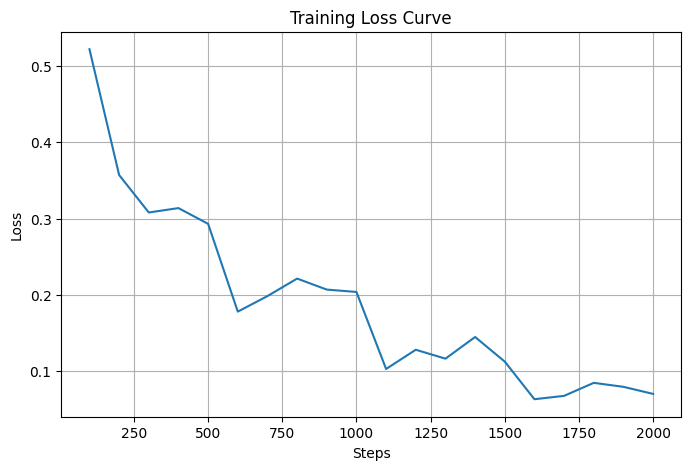

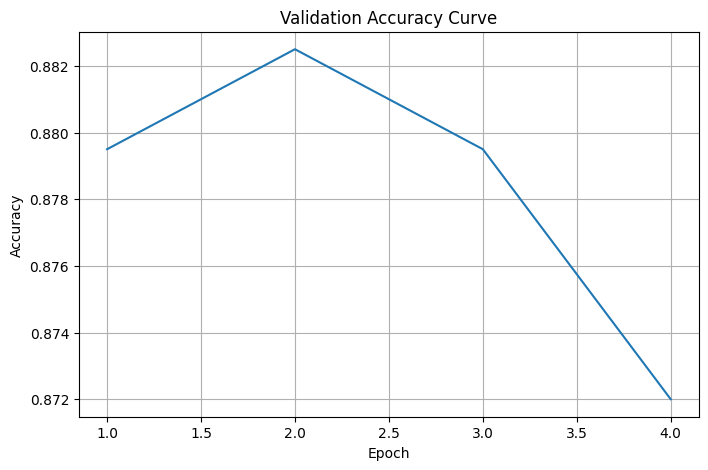

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model Saved Successfully

Prediction: Positive
Confidence: 99.14 %

Prediction: Negative
Confidence: 99.3 %


In [15]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

train_pos = "/content/aclImdb/train/pos"
train_neg = "/content/aclImdb/train/neg"

test_pos = "/content/aclImdb/test/pos"
test_neg = "/content/aclImdb/test/neg"

train_texts = []
train_labels = []

def load_reviews(folder, label, limit=None):

    files = os.listdir(folder)

    if limit:
        files = files[:limit]

    for file in files:

        path = os.path.join(folder, file)

        with open(path, encoding="utf8") as f:

            train_texts.append(f.read())
            train_labels.append(label)

load_reviews(train_pos, 1, 5000)
load_reviews(train_neg, 0, 5000)

print("Training Samples:", len(train_texts))

test_texts = []
test_labels = []

def load_test(folder, label, limit=None):

    files = os.listdir(folder)

    if limit:
        files = files[:limit]

    for file in files:

        path = os.path.join(folder, file)

        with open(path, encoding="utf8") as f:

            test_texts.append(f.read())
            test_labels.append(label)

load_test(test_pos, 1, 1000)
load_test(test_neg, 0, 1000)

print("Testing Samples:", len(test_texts))

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts,
    train_labels,
    test_size=0.2,
    random_state=42,
    stratify=train_labels
)

tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=256
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=256
)

train_dataset = Dataset.from_dict({
    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "labels": train_labels
})

val_dataset = Dataset.from_dict({
    "input_ids": val_encodings["input_ids"],
    "attention_mask": val_encodings["attention_mask"],
    "labels": val_labels
})

test_dataset = Dataset.from_dict({
    "input_ids": test_encodings["input_ids"],
    "attention_mask": test_encodings["attention_mask"],
    "labels": test_labels
})

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

def compute_metrics(pred):

    labels = pred.label_ids

    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=10,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    greater_is_better=True,

    logging_steps=100,

    save_total_limit=1,

    report_to="none"
)

trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

trainer.train()

print("\nEvaluating on Test Data...\n")

predictions = trainer.predict(test_dataset)

preds = np.argmax(
    predictions.predictions,
    axis=1
)

print(
    classification_report(
        test_labels,
        preds
    )
)

print(
    "Confusion Matrix\n"
)

print(
    confusion_matrix(
        test_labels,
        preds
    )
)

accuracy = accuracy_score(
    test_labels,
    preds
)

print(
    "\nTest Accuracy:",
    round(
        accuracy * 100,
        2
    ),
    "%"
)

history = pd.DataFrame(
    trainer.state.log_history
)

loss_history = history[
    history["loss"].notna()
]

eval_history = history[
    history["eval_accuracy"].notna()
]

plt.figure(figsize=(8,5))
plt.plot(
    loss_history["step"],
    loss_history["loss"]
)
plt.title("Training Loss Curve")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(
    eval_history["epoch"],
    eval_history["eval_accuracy"]
)
plt.title("Validation Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

trainer.save_model(
    "best_distilbert_imdb"
)

tokenizer.save_pretrained(
    "best_distilbert_imdb"
)

print("\nModel Saved Successfully")

def predict_review(text):

    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    encoded = {
        k:v.to(device)
        for k,v
        in encoded.items()
    }

    model.to(device)
    model.eval()

    with torch.no_grad():

        output = model(**encoded)

        probs = torch.softmax(
            output.logits,
            dim=1
        )

        prediction = torch.argmax(
            probs,
            dim=1
        ).item()

        confidence = (
            probs.max().item()
            * 100
        )

    sentiment = (
        "Positive"
        if prediction == 1
        else "Negative"
    )

    print("\nPrediction:", sentiment)

    print(
        "Confidence:",
        round(confidence,2),
        "%"
    )

predict_review(
    "This movie was absolutely fantastic. The acting and story were amazing."
)

predict_review(
    "This was one of the worst movies I have ever watched."
)

In [22]:
!find /content -name "*.ipynb"